In [1]:
!pip install transformers

In [2]:
import sys
print(sys.version)

3.10.16 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:19:12) [MSC v.1929 64 bit (AMD64)]


In [3]:
import torch
import warnings
warnings.filterwarnings("ignore")
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA available: True
Number of GPUs: 1
GPU Name: NVIDIA GeForce RTX 3090


In [4]:
!pip install librosa
!pip install datasets
!pip install --upgrade librosa soundfile audioread
!pip install --upgrade librosa
!pip install resampy
!pip install opendatasets
!sudo apt-get install libsndfile1
!pip install --upgrade librosa soundfile audioread
!pip install pydub

Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app


In [5]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
import cv2
import librosa

In [6]:
from glob import glob

path= r"audio_files\**\*" 
paths = glob(path, recursive=True)
audio_df = pd.DataFrame(paths, columns=['path'])
audio_df.head()

,path
0,audio_files\processed_audio_0.wav
1,audio_files\processed_audio_1.wav
2,audio_files\processed_audio_10.wav
3,audio_files\processed_audio_100.wav
4,audio_files\processed_audio_1000.wav


In [7]:
audio_df

,path
0,audio_files\processed_audio_0.wav
1,audio_files\processed_audio_1.wav
2,audio_files\processed_audio_10.wav
3,audio_files\processed_audio_100.wav
4,audio_files\processed_audio_1000.wav
...,...
22100,audio_files\processed_audio_9995.wav
22101,audio_files\processed_audio_9996.wav
22102,audio_files\processed_audio_9997.wav
22103,audio_files\processed_audio_9998.wav


In [8]:
from IPython.display import Audio
Audio(audio_df['path'][0])

In [9]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torch
import torchaudio

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
def extract_audio_features(audio_paths, model, processor):
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    features = []
    for path in audio_paths:
        waveform, sr = torchaudio.load(path)
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
            waveform = resampler(waveform)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        inputs = processor(waveform.squeeze(0), return_tensors="pt", sampling_rate=16000, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        features.append(outputs.last_hidden_state.mean(dim=1))
    return torch.cat(features, dim=0)
audio_paths = audio_df['path'].tolist()
audio_features = extract_audio_features(audio_paths,model,processor)
print(audio_features.shape)

torch.Size([22105, 768])


In [11]:
embeddings=audio_features
embeddings.shape

torch.Size([22105, 768])

In [12]:
embeddings

tensor([[ 0.0155,  0.0209, -0.0139,  ..., -0.1974,  0.0263,  0.0060],
        [-0.0284,  0.0149,  0.0672,  ..., -0.2240, -0.0046, -0.0843],
        [ 0.0225,  0.0161,  0.0355,  ..., -0.1947,  0.0457, -0.0473],
        ...,
        [-0.0134, -0.0047, -0.0175,  ..., -0.1871,  0.0354, -0.0140],
        [-0.0225, -0.0165, -0.0140,  ..., -0.1742,  0.0427, -0.0477],
        [ 0.0016,  0.0004, -0.0396,  ..., -0.2128,  0.0305, -0.0226]],
       device='cuda:0')

In [13]:
mean = embeddings.mean(dim=0, keepdim=True)
std = embeddings.std(dim=0, keepdim=True)
embeddings = (embeddings - mean) / std
embeddings

tensor([[ 0.9481,  0.6655,  0.5639,  ..., -0.6906,  0.3903,  0.4298],
        [-1.2415,  0.2239,  2.1102,  ..., -1.1752, -1.7219, -1.7666],
        [ 1.3001,  0.3156,  1.5055,  ..., -0.6426,  1.7193, -0.8663],
        ...,
        [-0.4943, -1.1986,  0.4951,  ..., -0.5037,  1.0162, -0.0561],
        [-0.9491, -2.0595,  0.5617,  ..., -0.2686,  1.5104, -0.8758],
        [ 0.2561, -0.8303,  0.0729,  ..., -0.9716,  0.6791, -0.2667]],
       device='cuda:0')

In [14]:
audio_df = audio_df.rename(columns={'path': 'audio_path'})
audio_df.insert(0, 'id', range(1, len(audio_df) + 1))
audio_df

,id,audio_path
0,1,audio_files\processed_audio_0.wav
1,2,audio_files\processed_audio_1.wav
2,3,audio_files\processed_audio_10.wav
3,4,audio_files\processed_audio_100.wav
4,5,audio_files\processed_audio_1000.wav
...,...,...
22100,22101,audio_files\processed_audio_9995.wav
22101,22102,audio_files\processed_audio_9996.wav
22102,22103,audio_files\processed_audio_9997.wav
22103,22104,audio_files\processed_audio_9998.wav


In [15]:
import os
import pandas as pd

valid_audio_records = []
missing_audio_records = []

for index, row in audio_df.iterrows():
    audio_path = row['audio_path']
    
    if os.path.exists(audio_path):
        valid_audio_records.append(row)  
    else:
        missing_audio_records.append(row) 

valid_audio_df = pd.DataFrame(valid_audio_records)
missing_audio_df = pd.DataFrame(missing_audio_records)

if not missing_audio_df.empty:
    print("Missing audio files:")
    print(missing_audio_df[['audio_path']]) 
else:
    print("All audio files exist.")

audio_df = valid_audio_df
audio_df

All audio files exist.


,id,audio_path
0,1,audio_files\processed_audio_0.wav
1,2,audio_files\processed_audio_1.wav
2,3,audio_files\processed_audio_10.wav
3,4,audio_files\processed_audio_100.wav
4,5,audio_files\processed_audio_1000.wav
...,...,...
22100,22101,audio_files\processed_audio_9995.wav
22101,22102,audio_files\processed_audio_9996.wav
22102,22103,audio_files\processed_audio_9997.wav
22103,22104,audio_files\processed_audio_9998.wav


In [16]:
embeddings= embeddings.detach().cpu().numpy()
embeddings

array([[ 0.9480836 ,  0.66554105,  0.5639007 , ..., -0.69057566,
         0.39033645,  0.4298098 ],
       [-1.2414662 ,  0.22387064,  2.110249  , ..., -1.1751684 ,
        -1.7218577 , -1.7666304 ],
       [ 1.3001013 ,  0.3155941 ,  1.5055262 , ..., -0.64264727,
         1.7192525 , -0.8663477 ],
       ...,
       [-0.49429056, -1.1985929 ,  0.49508306, ..., -0.50373954,
         1.0161988 , -0.05611089],
       [-0.94905996, -2.0595117 ,  0.56169236, ..., -0.26862437,
         1.5104294 , -0.8758029 ],
       [ 0.25607735, -0.83032656,  0.07294764, ..., -0.97160006,
         0.67906886, -0.2667155 ]], shape=(22105, 768), dtype=float32)

In [17]:
from sklearn.cluster import KMeans
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)
labels

array([2, 0, 0, ..., 2, 2, 2], shape=(22105,), dtype=int32)

In [18]:
labeled_audios = list(zip(audio_df['audio_path'],labels))
audio_df=pd.DataFrame(labeled_audios)
audio_df.rename(columns={0: "audio_path", 1: "label"}, inplace=True)
audio_df['label'].value_counts()

label
1    10281
2     7204
0     4620
Name: count, dtype: int64

In [19]:
label_mapping = {
    0: "Negative",
    1: "Positive",
    2:"Neutral"
    
}
audio_df['label'] = audio_df['label'].map(label_mapping)

In [20]:
audio_df

,audio_path,label
0,audio_files\processed_audio_0.wav,Neutral
1,audio_files\processed_audio_1.wav,Negative
2,audio_files\processed_audio_10.wav,Negative
3,audio_files\processed_audio_100.wav,Negative
4,audio_files\processed_audio_1000.wav,Negative
...,...,...
22100,audio_files\processed_audio_9995.wav,Neutral
22101,audio_files\processed_audio_9996.wav,Neutral
22102,audio_files\processed_audio_9997.wav,Neutral
22103,audio_files\processed_audio_9998.wav,Neutral


In [21]:
positive_sentiment= audio_df[audio_df['label'] =="Positive"]
positive= pd.DataFrame(positive_sentiment)
positive

,audio_path,label
23,audio_files\processed_audio_10017.wav,Positive
37,audio_files\processed_audio_1003.wav,Positive
48,audio_files\processed_audio_1004.wav,Positive
69,audio_files\processed_audio_10059.wav,Positive
70,audio_files\processed_audio_1006.wav,Positive
...,...,...
22018,audio_files\processed_audio_9920.wav,Positive
22019,audio_files\processed_audio_9921.wav,Positive
22028,audio_files\processed_audio_993.wav,Positive
22058,audio_files\processed_audio_9957.wav,Positive


In [22]:
def calculate_distance_to_centroid(row, centroids, embeddings, labels):
    index = row.name
    embedding = embeddings[index]
    cluster_label = labels[index]
    centroid = centroids[cluster_label]
    distance = np.linalg.norm(embedding - centroid)
    return distance

In [23]:
centroids = kmeans.cluster_centers_

In [24]:
positive.loc[:, 'distance_to_centroid'] = positive.apply(
    calculate_distance_to_centroid,
    axis=1,
    centroids=centroids,
    embeddings=embeddings,
    labels=labels
)

In [25]:
percentile_threshold = positive['distance_to_centroid'].quantile(0.3)

positive['label'] = positive['distance_to_centroid'].apply(lambda x: 'Highly Positive' if x < percentile_threshold else 'Positive')

In [26]:
audio_df= audio_df[audio_df['label'] != 'Positive']
audio_df=pd.concat([audio_df,positive],axis=0)
audio_df.drop(columns=['distance_to_centroid'],inplace=True,axis=1)

In [27]:
audio_df['label'].value_counts()

label
Neutral            7204
Positive           7197
Negative           4620
Highly Positive    3084
Name: count, dtype: int64

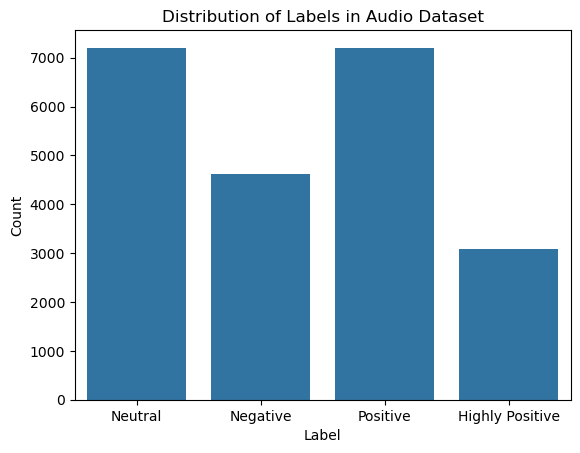

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='label', data=audio_df)
plt.title("Distribution of Labels in Audio Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [29]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"
import seaborn as sns
import matplotlib.pyplot as plt

label=audio_df['label'].value_counts()
label_values = label.value_counts().values
label_index = label.value_counts().index

fig = px.pie(audio_df,names='label',hole=0.6,title='Label Distribution')
fig.show()

In [30]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3090


In [31]:
label_mapping = {
    'Negative': 0,
    'Positive': 1,
    'Highly Positive': 2,
    'Neutral': 3,
}

audio_df['label'] = audio_df['label'].map(label_mapping)

In [32]:
audio_df['label'].value_counts()

label
3    7204
1    7197
0    4620
2    3084
Name: count, dtype: int64

In [33]:
audio_df

,audio_path,label
0,audio_files\processed_audio_0.wav,3
1,audio_files\processed_audio_1.wav,0
2,audio_files\processed_audio_10.wav,0
3,audio_files\processed_audio_100.wav,0
4,audio_files\processed_audio_1000.wav,0
...,...,...
22018,audio_files\processed_audio_9920.wav,1
22019,audio_files\processed_audio_9921.wav,1
22028,audio_files\processed_audio_993.wav,1
22058,audio_files\processed_audio_9957.wav,2


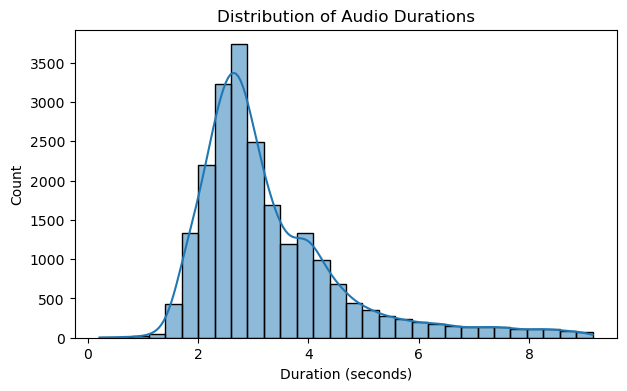

In [34]:
def calculate_duration(row):
    y, sr = librosa.load(row['audio_path'])
    return librosa.get_duration(y=y, sr=sr)

audio_df['Duration'] = audio_df.apply(calculate_duration, axis=1)

plt.figure(figsize=(7, 4))
sns.histplot(audio_df['Duration'], kde=True, bins=30)
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

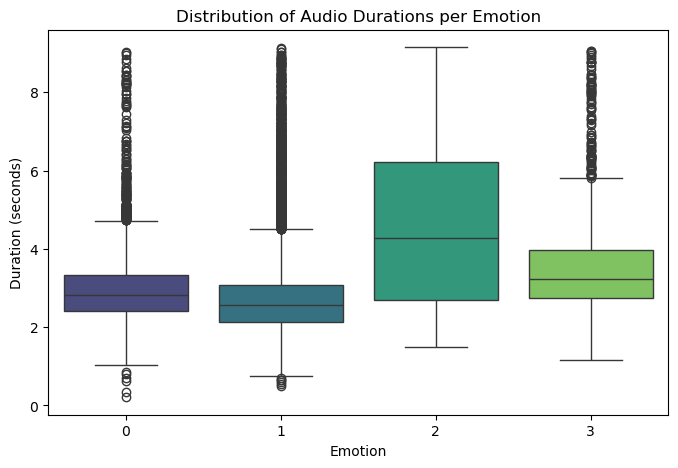

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='Duration', data=audio_df, palette='viridis')
plt.title('Distribution of Audio Durations per Emotion')
plt.xlabel('Emotion')
plt.ylabel('Duration (seconds)')
plt.show()

In [36]:
audio_df.drop('Duration', axis=1, inplace=True)

In [37]:
audio_df

,audio_path,label
0,audio_files\processed_audio_0.wav,3
1,audio_files\processed_audio_1.wav,0
2,audio_files\processed_audio_10.wav,0
3,audio_files\processed_audio_100.wav,0
4,audio_files\processed_audio_1000.wav,0
...,...,...
22018,audio_files\processed_audio_9920.wav,1
22019,audio_files\processed_audio_9921.wav,1
22028,audio_files\processed_audio_993.wav,1
22058,audio_files\processed_audio_9957.wav,2


In [38]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, TrainingArguments

def compute_metrics(p):
    preds = p.predictions.argmax(axis=-1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=1)
    accuracy = accuracy_score(labels, preds)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [39]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.6.0+cu118
CUDA available: True


In [40]:
from datasets import Dataset, DatasetDict
dataset = Dataset.from_dict(audio_df)
dataset

Dataset({
    features: ['audio_path', 'label'],
    num_rows: 22105
})

In [41]:
from sklearn.model_selection import train_test_split
dataset= dataset.train_test_split(test_size=0.25, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['audio_path', 'label'],
        num_rows: 16578
    })
    test: Dataset({
        features: ['audio_path', 'label'],
        num_rows: 5527
    })
})

In [42]:
from transformers import AutoFeatureExtractor
from transformers import AutoModelForAudioClassification
import warnings
warnings.filterwarnings('ignore')

model_name="xmj2002/hubert-base-ch-speech-emotion-recognition"
feature= AutoFeatureExtractor.from_pretrained(model_name)
model=AutoModelForAudioClassification.from_pretrained(model_name,num_labels=4,ignore_mismatched_sizes=True).to("cuda").eval()

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at xmj2002/hubert-base-ch-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
def preprocess_audio(batch):
    audio, _ = librosa.load(batch['audio_path'], sr=16000)
    inputs = feature(audio, sampling_rate=16000, return_tensors="pt")
    batch['input_values'] = inputs['input_values'].squeeze()
    return batch

encode_dataset = dataset.map(preprocess_audio, remove_columns=['audio_path'], batch_size=4)

Map:   0%|          | 0/16578 [00:00<?, ? examples/s]

Map:   0%|          | 0/5527 [00:00<?, ? examples/s]

In [44]:
encode_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_values'],
        num_rows: 16578
    })
    test: Dataset({
        features: ['label', 'input_values'],
        num_rows: 5527
    })
})

In [45]:
test_dataset=encode_dataset['test']
test_dataset

Dataset({
    features: ['label', 'input_values'],
    num_rows: 5527
})

In [169]:
from transformers import Trainer, TrainingArguments,EarlyStoppingCallback
from transformers import get_scheduler, DefaultDataCollator
import torch
from torch.optim import AdamW
import warnings
warnings.filterwarnings('ignore')

model = model.float().to('cuda')
model.config.hidden_dropout_prob = 0.5
optimizer = AdamW(model.parameters(), weight_decay=0.3, eps=1e-8, betas=(0.9, 0.999))

training_args = TrainingArguments(
    output_dir="./audio-emotion-tuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=13,
    logging_dir="./logs",
    logging_steps=100,
    warmup_steps=500,
    save_steps=1000,
    eval_steps=100,
    seed=42,
    lr_scheduler_type='linear',
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1",  
    dataloader_num_workers=0,
    dataloader_pin_memory=True,
    dataloader_drop_last=True,
    dataloader_persistent_workers=False,
    fp16=True,
    fp16_full_eval=True,
    fp16_opt_level=None,
    report_to='none',
    warmup_ratio=0.1,
    max_grad_norm=1.0,

)

In [170]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model =model.to(device)

In [171]:
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback
from transformers import Trainer

data_collator = DataCollatorWithPadding(feature)
callbacks = [EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01)]
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encode_dataset['train'],
    eval_dataset=encode_dataset['test'],
    data_collator=data_collator,
    tokenizer=feature,
    compute_metrics=compute_metrics,
    callbacks=callbacks, 
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.723800,0.740499,0.685326,0.683095,0.685326,0.677208
2,0.635400,0.674814,0.713225,0.712102,0.713225,0.712318
3,0.650200,0.674841,0.716848,0.724110,0.716848,0.710476


TrainOutput(global_step=6216, training_loss=0.7531406158339257, metrics={'train_runtime': 2839.6839, 'train_samples_per_second': 17.514, 'train_steps_per_second': 2.189, 'total_flos': 2.5794940913335665e+18, 'train_loss': 0.7531406158339257, 'epoch': 3.0})

In [172]:
trainer.evaluate()

{'eval_loss': 0.6748347878456116,
 'eval_accuracy': 0.7132246376811594,
 'eval_precision': 0.7121016119436022,
 'eval_recall': 0.7132246376811594,
 'eval_f1': 0.7123175252824522,
 'eval_runtime': 217.7823,
 'eval_samples_per_second': 25.379,
 'eval_steps_per_second': 3.173,
 'epoch': 3.0}

In [173]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,ConfusionMatrixDisplay
import numpy as np

predictions, labels, _ = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

array([3, 0, 1, ..., 2, 1, 0], shape=(5520,))

In [174]:
cm=confusion_matrix(labels,predicted_labels)
cm

array([[ 760,  118,    2,  302],
       [ 115, 1366,  235,  129],
       [   6,  308,  455,    3],
       [ 316,   47,    2, 1356]])

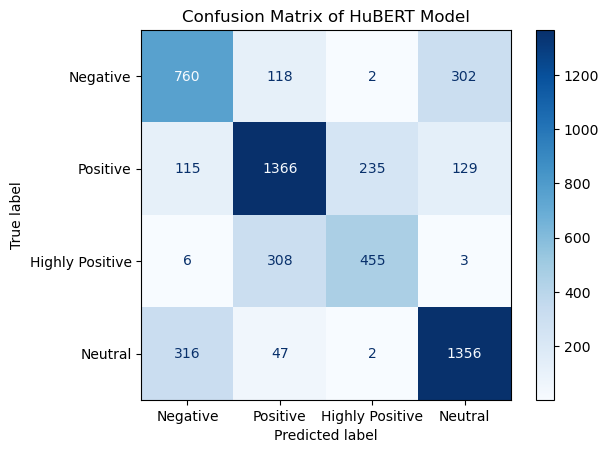

In [175]:
disp = ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive","Highly Positive","Neutral"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix of HuBERT Model")
plt.show()

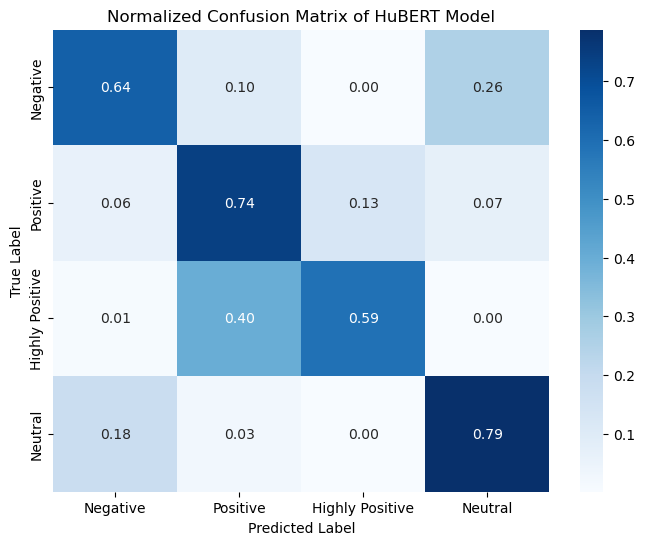

In [176]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=["Negative","Positive","Highly Positive","Neutral"], yticklabels=["Negative","Positive","Highly Positive","Neutral"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Normalized Confusion Matrix of HuBERT Model')
plt.show()

In [177]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_labels, labels=[0,1,2,3], target_names=["Negative","Positive","Highly Positive","Neutral"])
print(report)

                 precision    recall  f1-score   support

       Negative       0.63      0.64      0.64      1182
       Positive       0.74      0.74      0.74      1845
Highly Positive       0.66      0.59      0.62       772
        Neutral       0.76      0.79      0.77      1721

       accuracy                           0.71      5520
      macro avg       0.70      0.69      0.69      5520
   weighted avg       0.71      0.71      0.71      5520



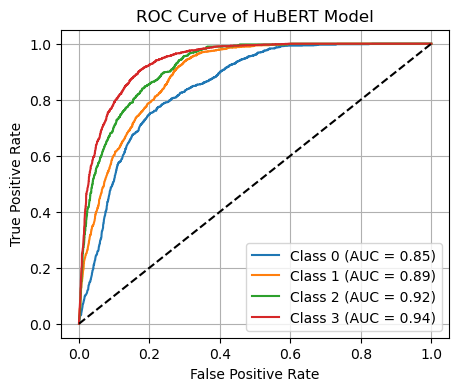

In [178]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

predicted_probs = predictions

true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(5,4))

for i in range(true_labels_binarized.shape[1]):
    fpr, tpr, thresholds = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of HuBERT Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.show()

Shape of true_labels_binarized: (5520, 4)
Shape of predicted_probs: (5520, 4)


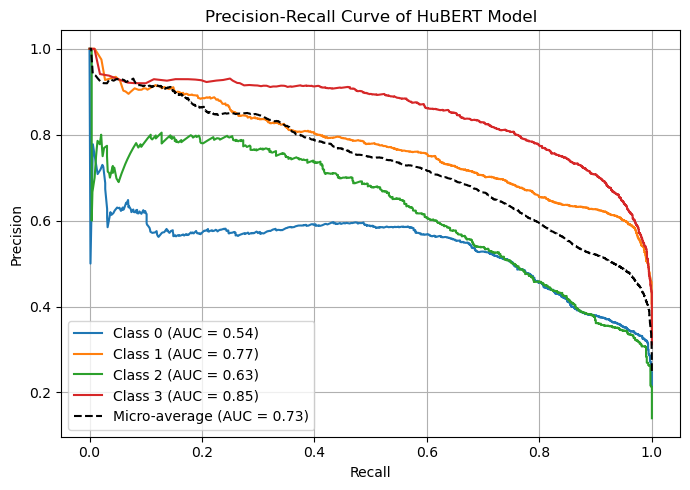

In [179]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

predicted_probs = predicted_probs[:, :4]
true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

print(f"Shape of true_labels_binarized: {true_labels_binarized.shape}")
print(f"Shape of predicted_probs: {predicted_probs.shape}")

precision, recall, pr_auc = {}, {}, {}
for i in range(true_labels_binarized.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

precision_micro, recall_micro, _ = precision_recall_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

for i in range(true_labels_binarized.shape[1]):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {pr_auc[i]:.2f})')

plt.plot(recall_micro, precision_micro, label=f'Micro-average (AUC = {pr_auc_micro:.2f})', linestyle='--', color='black')

plt.title('Precision-Recall Curve of HuBERT Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

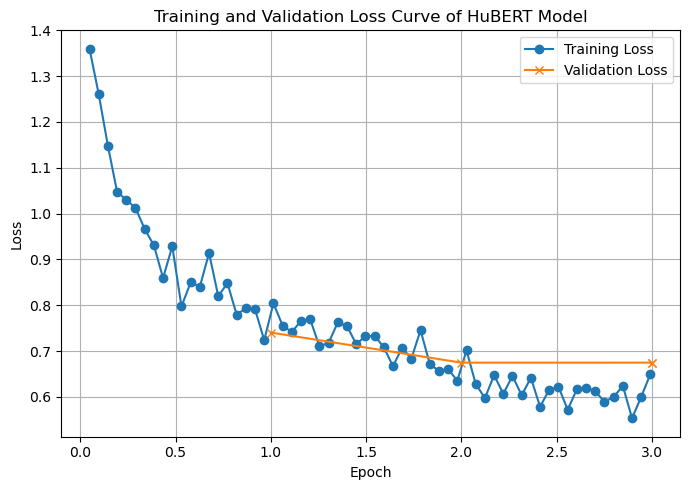

In [180]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Extract trainer state log history
trainer_state = trainer.state
log_history = trainer_state.log_history

# Aggregate training loss per epoch
epoch_train_loss = defaultdict(list)
for log in log_history:
    if 'loss' in log and 'epoch' in log:
        epoch_train_loss[float(log['epoch'])].append(log['loss'])  # Use float to match eval

# Average training loss per epoch
train_epochs = sorted(epoch_train_loss.keys())
avg_train_loss = [sum(epoch_train_loss[ep]) / len(epoch_train_loss[ep]) for ep in train_epochs]

# Extract evaluation loss per epoch (ensure float for epoch)
eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log and 'epoch' in log]
eval_steps = [float(log['epoch']) for log in log_history if 'eval_loss' in log and 'epoch' in log]

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(train_epochs, avg_train_loss, label="Training Loss", marker='o', linestyle='-')
if eval_loss and eval_steps:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", marker='x', linestyle='-')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve of HuBERT Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


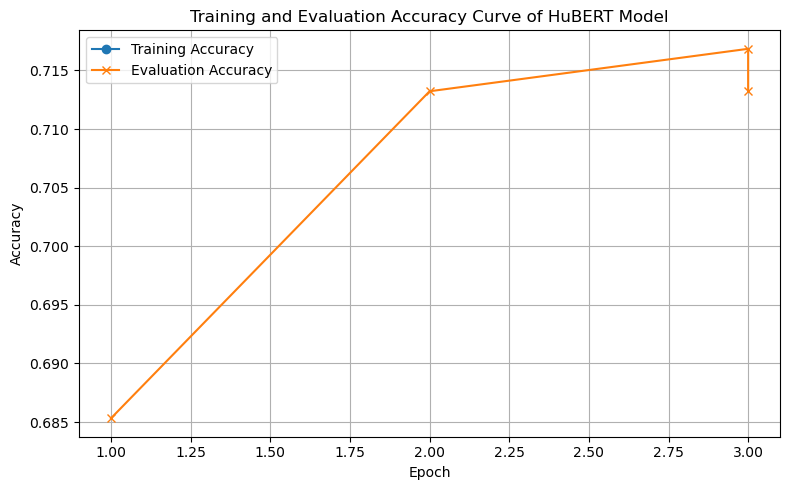

In [181]:
from collections import defaultdict
import matplotlib.pyplot as plt

trainer_state = trainer.state
log_history = trainer_state.log_history

# Group and average training accuracy per epoch
train_acc_per_epoch = defaultdict(list)
for log in log_history:
    if 'train_accuracy' in log and 'epoch' in log:
        train_acc_per_epoch[float(log['epoch'])].append(log['train_accuracy'])

train_epochs = sorted(train_acc_per_epoch.keys())
avg_train_acc = [sum(train_acc_per_epoch[ep]) / len(train_acc_per_epoch[ep]) for ep in train_epochs]

# Get evaluation accuracy per epoch
eval_accuracy = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log and 'epoch' in log]
eval_epochs = [float(log['epoch']) for log in log_history if 'eval_accuracy' in log and 'epoch' in log]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, avg_train_acc, label="Training Accuracy", marker='o', linestyle='-')
if eval_accuracy:
    plt.plot(eval_epochs, eval_accuracy, label="Evaluation Accuracy", marker='x', linestyle='-')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Evaluation Accuracy Curve of HuBERT Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Wav2Vec Model

In [182]:
dataset

DatasetDict({
    train: Dataset({
        features: ['audio_path', 'label'],
        num_rows: 16578
    })
    test: Dataset({
        features: ['audio_path', 'label'],
        num_rows: 5527
    })
})

In [183]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor
import torch
import torchaudio

model_name = "facebook/wav2vec2-large-xlsr-53"
wav2vec_processor= Wav2Vec2FeatureExtractor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2ForSequenceClassification.from_pretrained(model_name, num_labels=4,ignore_mismatched_sizes=True).to("cuda").eval()

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [184]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def transform(example):
    speech_array, sampling_rate = torchaudio.load(example["audio_path"])
    
    if sampling_rate != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sampling_rate, new_freq=16000)
        speech_array = resampler(speech_array)
    speech_array = speech_array.squeeze().numpy()
    input_values = wav2vec_processor(speech_array,sampling_rate=16000,return_tensors="pt").input_values[0].to(device)
    return {"input_values": input_values, "label": example["label"]}

wav2vec_dataset = dataset.map(transform, remove_columns=["audio_path"], batched=False)

Map:   0%|          | 0/16578 [00:00<?, ? examples/s]

Map:   0%|          | 0/5527 [00:00<?, ? examples/s]

In [185]:
wav2vec_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_values'],
        num_rows: 16578
    })
    test: Dataset({
        features: ['label', 'input_values'],
        num_rows: 5527
    })
})

In [186]:
test_dataset=wav2vec_dataset['test']
test_dataset

Dataset({
    features: ['label', 'input_values'],
    num_rows: 5527
})

In [189]:
from transformers import Trainer, TrainingArguments,EarlyStoppingCallback
from transformers import get_scheduler, DefaultDataCollator
import torch
from torch.optim import AdamW
import warnings
warnings.filterwarnings('ignore')

wav2vec_model= wav2vec_model.float().to('cuda')
wav2vec_model.config.hidden_dropout_prob = 0.5
optimizer = AdamW(wav2vec_model.parameters(), weight_decay=0.3, eps=1e-8, betas=(0.9, 0.999))

training_args = TrainingArguments(
    output_dir="./wav2vec-tuning",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=7,
    logging_dir="./logs",
    logging_steps=100,
    warmup_steps=500,
    save_steps=1000,
    eval_steps=100,
    seed=42,
    lr_scheduler_type='linear',
    remove_unused_columns=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1",  
    dataloader_num_workers=0,
    dataloader_pin_memory=True,
    dataloader_drop_last=True,
    dataloader_persistent_workers=False,
    fp16=True,
    fp16_full_eval=True,
    fp16_opt_level=None,
    report_to='none',
    warmup_ratio=0.1,
    max_grad_norm=1.0,
)

In [190]:
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback
from transformers import Trainer

data_collator = DataCollatorWithPadding(wav2vec_processor)
callbacks = [EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01)]
trainer = Trainer(
    model=wav2vec_model,
    args=training_args,
    train_dataset=wav2vec_dataset['train'],
    eval_dataset=wav2vec_dataset['test'],
    data_collator=data_collator,
    tokenizer=wav2vec_processor,
    compute_metrics=compute_metrics,
    callbacks=callbacks, 
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.750200,0.736820,0.682609,0.698301,0.682609,0.662063
2,0.683600,0.689153,0.708152,0.706618,0.708152,0.705420
3,0.683100,0.839713,0.664312,0.702896,0.664312,0.645030
4,0.575600,0.676157,0.721196,0.722731,0.721196,0.715651
5,0.574800,0.641513,0.738406,0.740256,0.738406,0.732965
6,0.495500,0.756656,0.727174,0.732376,0.727174,0.722129
7,0.423500,0.784252,0.729891,0.739878,0.729891,0.721486


TrainOutput(global_step=14504, training_loss=0.6369513339649164, metrics={'train_runtime': 8998.1873, 'train_samples_per_second': 12.897, 'train_steps_per_second': 1.612, 'total_flos': 2.005631741768035e+19, 'train_loss': 0.6369513339649164, 'epoch': 7.0})

In [191]:
trainer.evaluate()

{'eval_loss': 0.6412102580070496,
 'eval_accuracy': 0.7398550724637681,
 'eval_precision': 0.7415814636337843,
 'eval_recall': 0.7398550724637681,
 'eval_f1': 0.7345291404473299,
 'eval_runtime': 244.5295,
 'eval_samples_per_second': 22.603,
 'eval_steps_per_second': 2.826,
 'epoch': 7.0}

In [192]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,ConfusionMatrixDisplay
import numpy as np

predictions, labels, _ = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)
predicted_labels

array([3, 3, 0, ..., 2, 1, 1], shape=(5520,))

In [193]:
cm=confusion_matrix(labels,predicted_labels)
cm

array([[ 654,  102,    1,  425],
       [  75, 1392,  272,  106],
       [   2,  277,  491,    2],
       [ 115,   57,    2, 1547]])

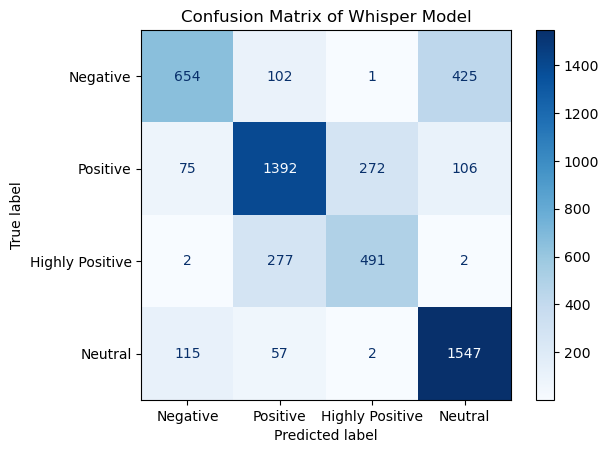

In [194]:
disp = ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive","Highly Positive","Neutral"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix of Whisper Model")
plt.show()

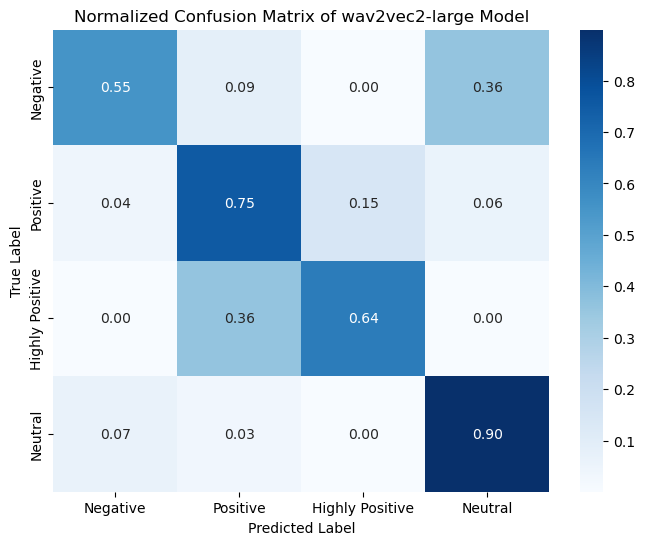

In [195]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=["Negative","Positive","Highly Positive","Neutral"], yticklabels=["Negative","Positive","Highly Positive","Neutral"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Normalized Confusion Matrix of wav2vec2-large Model')
plt.show()

In [196]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_labels, labels=[0,1,2,3], target_names=["Negative","Positive","Highly Positive","Neutral"])
print(report)

                 precision    recall  f1-score   support

       Negative       0.77      0.55      0.64      1182
       Positive       0.76      0.75      0.76      1845
Highly Positive       0.64      0.64      0.64       772
        Neutral       0.74      0.90      0.81      1721

       accuracy                           0.74      5520
      macro avg       0.73      0.71      0.71      5520
   weighted avg       0.74      0.74      0.73      5520



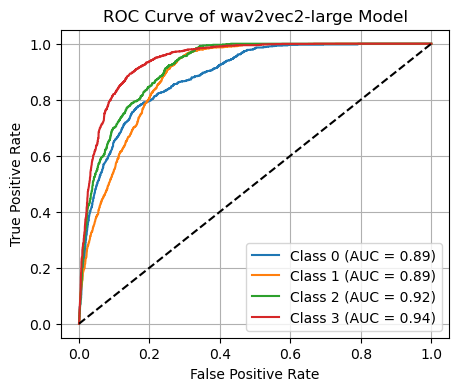

In [197]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

predicted_probs = predictions

true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

plt.figure(figsize=(5,4))

for i in range(true_labels_binarized.shape[1]):
    fpr, tpr, thresholds = roc_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of wav2vec2-large Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
plt.show()

Shape of true_labels_binarized: (5520, 4)
Shape of predicted_probs: (5520, 4)


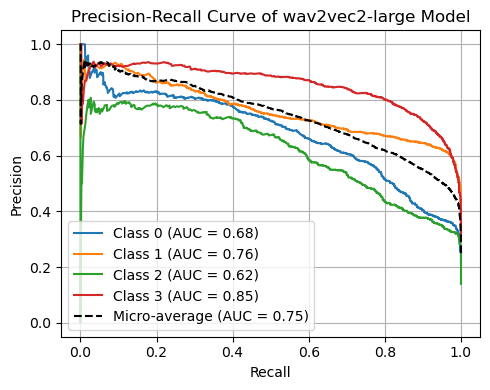

In [198]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

predicted_probs = predicted_probs[:, :4]
true_labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])

print(f"Shape of true_labels_binarized: {true_labels_binarized.shape}")
print(f"Shape of predicted_probs: {predicted_probs.shape}")

precision, recall, pr_auc = {}, {}, {}
for i in range(true_labels_binarized.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_binarized[:, i], predicted_probs[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

precision_micro, recall_micro, _ = precision_recall_curve(true_labels_binarized.ravel(), predicted_probs.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)

import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))

for i in range(true_labels_binarized.shape[1]):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AUC = {pr_auc[i]:.2f})')

plt.plot(recall_micro, precision_micro, label=f'Micro-average (AUC = {pr_auc_micro:.2f})', linestyle='--', color='black')

plt.title('Precision-Recall Curve of wav2vec2-large Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

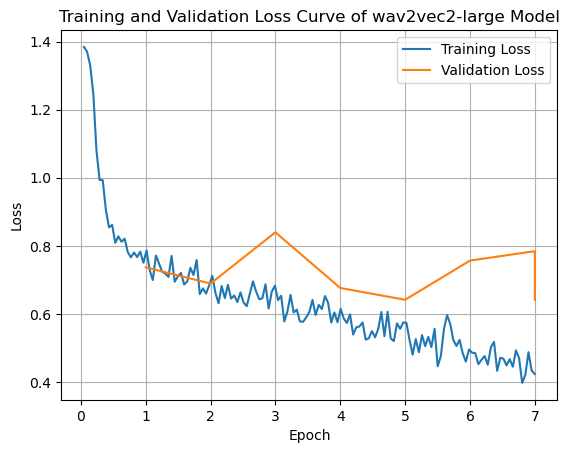

In [199]:
trainer_state = trainer.state
train_loss = [log['loss'] for log in trainer_state.log_history if 'loss' in log]
train_steps = [log['epoch'] for log in trainer_state.log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in trainer_state.log_history if 'eval_loss' in log]
eval_steps = [log['epoch'] for log in trainer_state.log_history if 'eval_loss' in log]
plt.plot(train_steps, train_loss, label="Training Loss")
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve of wav2vec2-large Model")
plt.legend()
plt.grid()
plt.show()


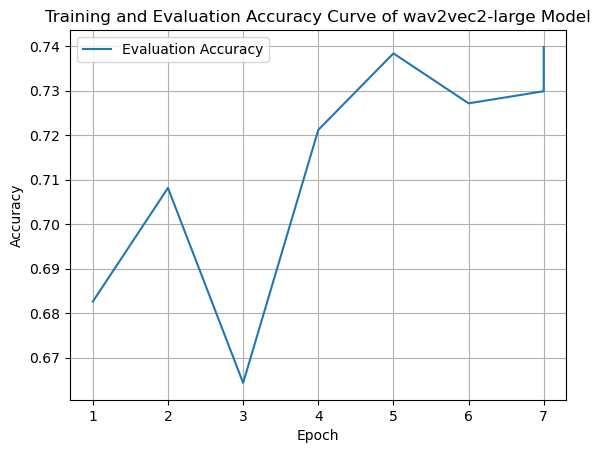

In [200]:
trainer_state = trainer.state
train_accuracy = [log['train_accuracy'] for log in trainer_state.log_history if 'train_accuracy' in log]
train_epoch = [log['epoch'] for log in trainer_state.log_history if 'train_accuracy' in log]

eval_accuracy = [log['eval_accuracy'] for log in trainer_state.log_history if 'eval_accuracy' in log]
eval_epoch = [log['epoch'] for log in trainer_state.log_history if 'eval_accuracy' in log]

if train_accuracy:
    plt.plot(train_epoch, train_accuracy, label="Training Accuracy")

if eval_accuracy:
    plt.plot(eval_epoch, eval_accuracy, label="Evaluation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Evaluation Accuracy Curve of wav2vec2-large Model")
plt.legend()
plt.grid()
plt.show()